# Monte Carlo Simulation for Mutual Fund NAV Forecasting

## Objective

The objective of this notebook is to forecast potential future NAV values of mutual fund schemes using Monte Carlo Simulation.

Monte Carlo Simulation generates thousands of possible future market scenarios based on historical return distributions and volatility. This helps estimate:

- Expected Future NAV
- Best-Case Scenario
- Worst-Case Scenario
- Uncertainty Bands
- Risk Exposure

The analysis is performed using historical NAV data from the Mutual Fund Analytics Platform.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

## Load Historical NAV Data

The NAV history dataset contains daily NAV values for all mutual fund schemes.

In [3]:
nav = pd.read_csv("../data/processed/clean_02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)

nav.head()

(46006, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


## Select Fund for Forecasting

For demonstration purposes, Nippon Large Cap fund (AMFI Code: 118632) is selected.

In [8]:
fund_code = 118632

fund = (
    nav[nav["amfi_code"] == fund_code]
    .sort_values("date")
    .copy()
)

print(fund.shape)

fund.head()

(1151, 3)


,amfi_code,date,nav
10350,118632,2022-01-03,42.8339
10351,118632,2022-01-04,42.8033
10352,118632,2022-01-05,43.0564
10353,118632,2022-01-06,43.2088
10354,118632,2022-01-07,42.9585


## Historical NAV Trend

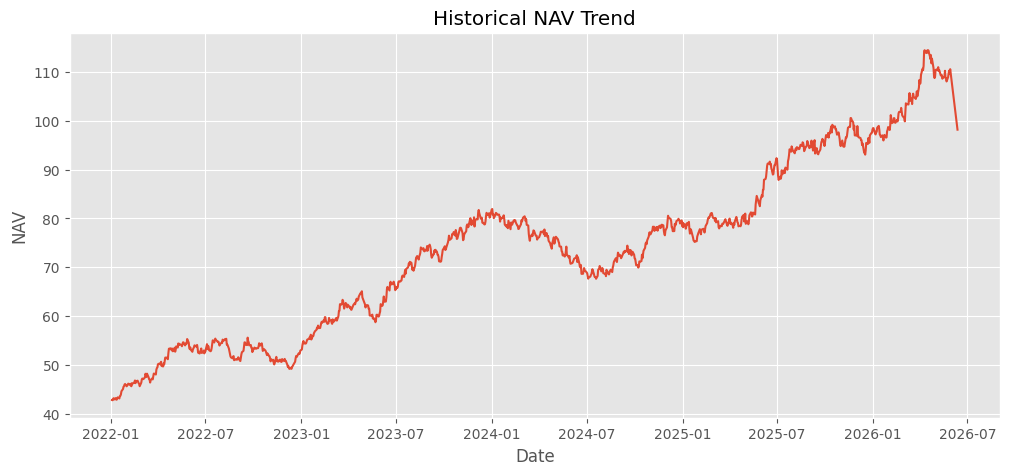

In [9]:
plt.figure(figsize=(12,5))

plt.plot(
    fund["date"],
    fund["nav"]
)

plt.title("Historical NAV Trend")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.show()

## Calculate Daily Returns

Daily returns will be used to estimate average return and volatility.

In [10]:
fund["daily_return"] = (
    fund["nav"]
    .pct_change()
)

returns = fund["daily_return"].dropna()

returns.head()

10351   -0.000714
10352    0.005913
10353    0.003540
10354   -0.005793
10355    0.006360
Name: daily_return, dtype: float64

In [11]:
mu = returns.mean()

sigma = returns.std()

print("Mean Daily Return:", round(mu,6))

print("Daily Volatility:", round(sigma,6))

Mean Daily Return: 0.000767
Daily Volatility: 0.00951


## Simulation Parameters

- Forecast Horizon: 5 Years
- Trading Days per Year: 252
- Simulations: 5,000

In [12]:
current_nav = fund["nav"].iloc[-1]
years = 5
trading_days = 252
forecast_days = years * trading_days
num_simulations = 5000

print("Current NAV:", current_nav)

Current NAV: 98.1776


## Run Monte Carlo Simulation

In [13]:
simulations = np.zeros(
    (forecast_days, num_simulations)
)

for sim in range(num_simulations):
    prices = [current_nav]

    for day in range(forecast_days):
        shock = np.random.normal(
            mu,
            sigma
        )

        next_price = prices[-1] * (1 + shock)
        prices.append(next_price)
        
    simulations[:, sim] = prices[1:]

## Plot Sample Simulation Paths

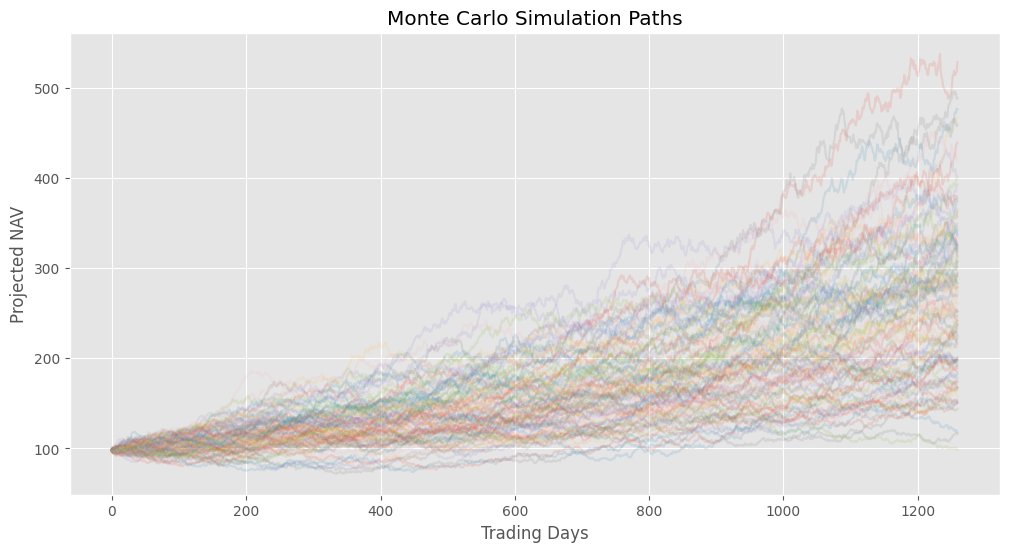

In [14]:
plt.figure(figsize=(12,6))

for i in range(100):

    plt.plot(
        simulations[:, i],
        alpha=0.15
)

plt.title(
    "Monte Carlo Simulation Paths"
)

plt.xlabel("Trading Days")

plt.ylabel("Projected NAV")

plt.show()

## Confidence Interval Analysis

The simulation paths are summarized using:

- Mean Forecast
- 5th Percentile
- 95th Percentile

In [15]:
mean_path = simulations.mean(axis=1)

lower_band = np.percentile(
    simulations,
    5,
    axis=1
)

upper_band = np.percentile(
    simulations,
    95,
    axis=1
)

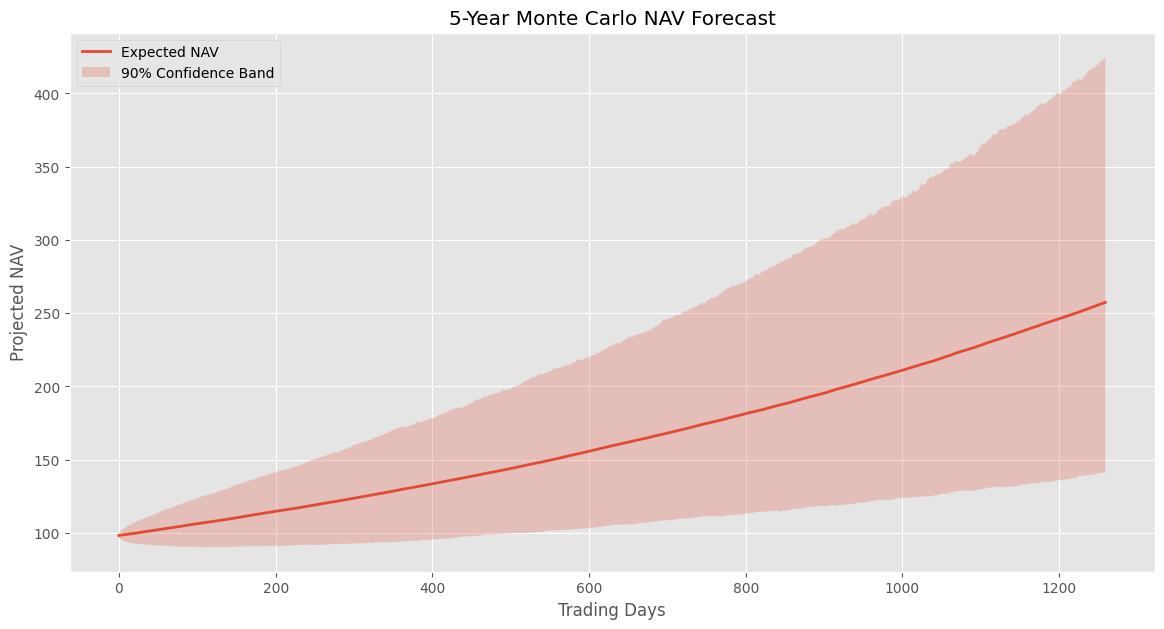

In [16]:
plt.figure(figsize=(14,7))

plt.plot(
    mean_path,
    linewidth=2,
    label="Expected NAV"
)

plt.fill_between(
    range(forecast_days),
    lower_band,
    upper_band,
    alpha=0.25,
    label="90% Confidence Band"
)

plt.title(
    "5-Year Monte Carlo NAV Forecast"
)

plt.xlabel("Trading Days")

plt.ylabel("Projected NAV")

plt.legend()

plt.show()

## Forecast Results

In [17]:
final_values = simulations[-1]

expected_nav = final_values.mean()

worst_case = np.percentile(
    final_values,
    5
)

best_case = np.percentile(
    final_values,
    95
)

forecast_df = pd.DataFrame({
    "Metric":[
        "Current NAV",
        "Expected NAV (5Y)",
        "Worst Case (5%)",
        "Best Case (95%)"
    ],
    "Value":[
        current_nav,
        expected_nav,
        worst_case,
        best_case
    ]
})

forecast_df

,Metric,Value
0,Current NAV,98.177600
1,Expected NAV (5Y),257.368229
2,Worst Case (5%),140.926146
3,Best Case (95%),424.748973


## Business Interpretation

The Monte Carlo simulation generated 5,000 possible future NAV paths over a five-year horizon.

Key observations:

- The expected NAV represents the average outcome across all simulations.
- The lower confidence band represents downside risk.
- The upper confidence band represents optimistic market scenarios.
- The widening confidence interval demonstrates increasing uncertainty over longer investment horizons.

This analysis reinforces the importance of long-term investing and risk-aware portfolio management.

# Conclusion

Monte Carlo Simulation provides a probabilistic view of future fund performance rather than a single-point forecast.

The model helps investors understand:

- Expected growth potential
- Downside risk
- Range of possible outcomes
- Impact of market volatility

This technique complements traditional performance metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and